# Feedforward Neural Network — Hyperparam tuning

### Experiment plan (as recommended in feedback from presentation)
1. **Multi-seed baseline** — run default config 5 seeds, report mean ± std
2. **Weight decay sweep** — λ ∈ {0, 1e-5, 1e-4, 1e-3, 1e-2}, 3 seeds each
3. **Dropout sweep** — p ∈ {0, 0.1, 0.2, 0.3, 0.5}, 3 seeds each
4. **Batch size sweep** — B ∈ {16, 32, 64}, 3 seeds each
5. **Learning rate sweep** — η ∈ {3e-4, 1e-3, 3e-3}, 3 seeds each
6. **Final tuned model** — combine best hyperparams, 5 seeds, compare to baseline

Total: ~56 runs.

In [32]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data_pipeline import prepare_data, FEATURE_COLS, TRAIN_YEARS, TEST_YEARS
from src.evaluate import compute_mae, compute_rmse, plot_pred_vs_actual, print_metrics
from src.baseline_pythagorean import pythagorean_predict
from src.neural_net import (
    WinPredictor, run_single, run_multi_seed,
    run_weight_decay_sweep, run_dropout_sweep,
    run_batch_size_sweep, run_learning_rate_sweep,
    run_architecture_search, run_sweep,
    plot_training_curve, plot_sweep_results,
    plot_multi_seed_distribution, plot_architecture_comparison,
    plot_final_comparison, predict,
    DEVICE, HIDDEN1, HIDDEN2, LEARNING_RATE, BATCH_SIZE,
    NUM_EPOCHS, WEIGHT_DECAY, DROPOUT_RATE, PATIENCE, RESULTS_DIR,
)

os.makedirs(RESULTS_DIR, exist_ok=True)

In [33]:
data = prepare_data()
X_train = data['X_train_scaled']
y_train = data['y_train']
X_test  = data['X_test_scaled']
y_test  = data['y_test']
print('Train:', X_train.shape[0], 'rows   Test:', X_test.shape[0], 'rows')
print('Features:', len(data['feature_names']))

Train: 570 rows   Test: 150 rows
Features: 15


---
## Step 1 — Multi-seed baseline (5 seeds)

Run the default config (64→32, lr=1e-3, wd=1e-4, dropout=0.2, B=32) with seeds 0–4.
To establish the variance band before we change anything.

In [35]:
print('Step 1: Multi-seed baseline (5 seeds)')
baseline_ms = run_multi_seed(X_train, y_train, X_test, y_test, n_seeds=5)
print('-----')
for i, s in enumerate(baseline_ms['seeds']):
    r = baseline_ms['per_seed'][i]
    print(f"  Seed {s}: MAE={r['mae']:.2f}  RMSE={r['rmse']:.2f}  best_epoch={r['best_epoch']}")
print('-----')
print(f"MAE: {baseline_ms['mae_mean']:.2f} +/- {baseline_ms['mae_std']:.2f}")
print(f"RMSE: {baseline_ms['rmse_mean']:.2f} +/- {baseline_ms['rmse_std']:.2f}")

Step 1: Multi-seed baseline (5 seeds)
-----
  Seed 0: MAE=9.92  RMSE=12.64  best_epoch=222
  Seed 1: MAE=10.15  RMSE=12.99  best_epoch=263
  Seed 2: MAE=10.23  RMSE=13.05  best_epoch=236
  Seed 3: MAE=9.84  RMSE=12.71  best_epoch=193
  Seed 4: MAE=10.22  RMSE=13.24  best_epoch=168
-----
MAE: 10.07 +/- 0.16
RMSE: 12.93 +/- 0.22


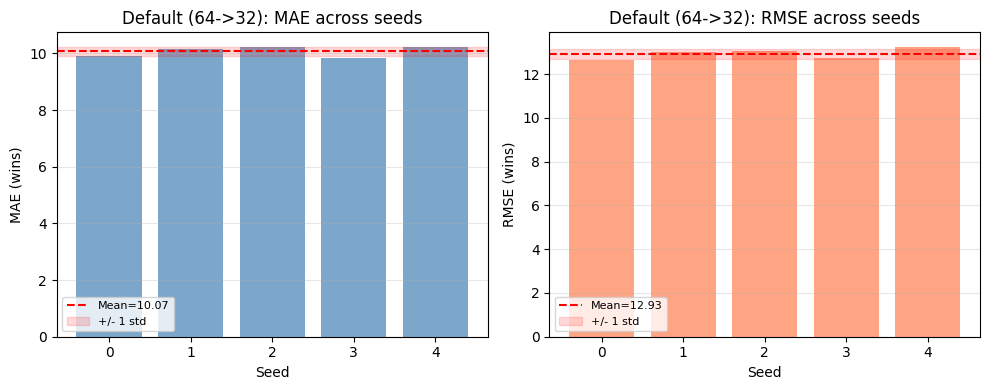

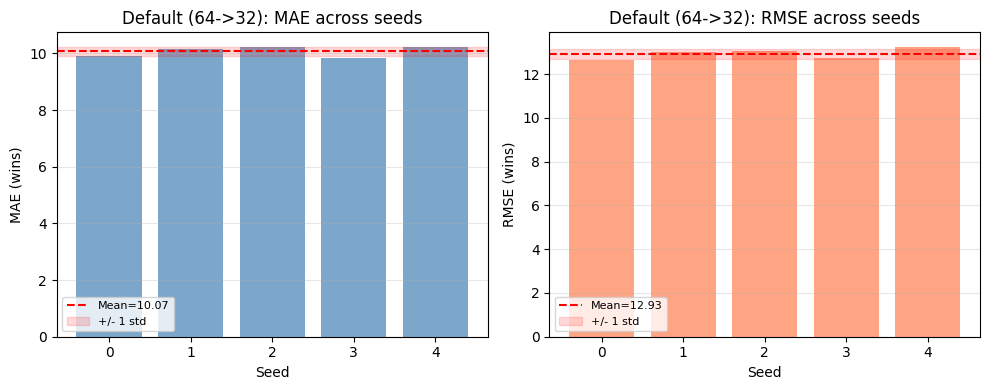

In [36]:
plot_multi_seed_distribution(baseline_ms, model_name='Default (64->32)', save_path=os.path.join(RESULTS_DIR, 'step1_multi_seed_baseline.png'), show=True)

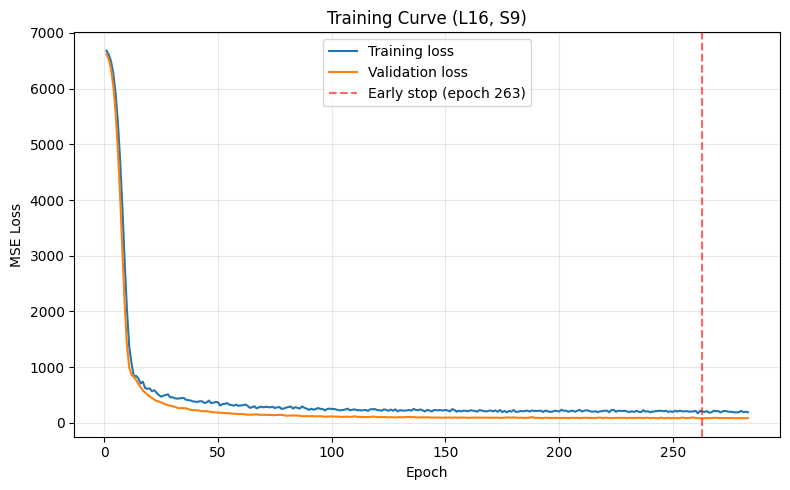

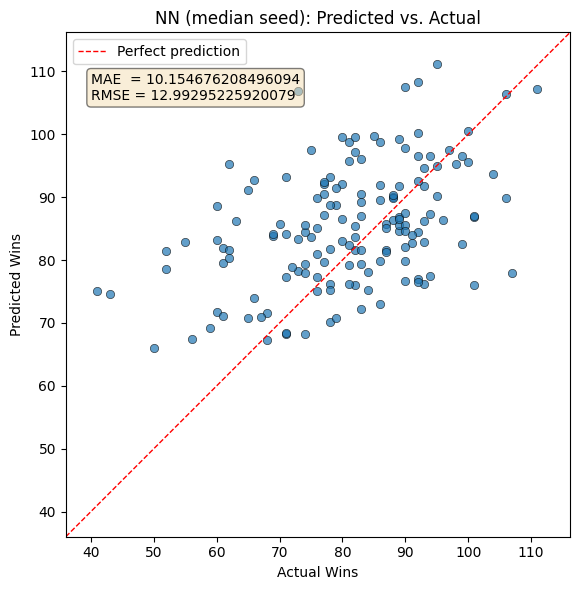

<Axes: title={'center': 'NN (median seed): Predicted vs. Actual'}, xlabel='Actual Wins', ylabel='Predicted Wins'>

In [48]:
median_idx = int(np.argsort(baseline_ms['maes'])[len(baseline_ms['maes']) // 2])
median_run = baseline_ms['per_seed'][median_idx]
plot_training_curve(median_run['train_losses'], median_run['val_losses'], median_run['best_epoch'], save_path=os.path.join(RESULTS_DIR, 'step1_training_curve_median.png'), show=True)
plot_pred_vs_actual(y_test, median_run['preds'], model_name='NN (median seed)', save_path=os.path.join(RESULTS_DIR, 'step1_pred_vs_actual_median.png'), show=True)

---
## Step 2 — Weight decay

λ ∈ {0, 1e-5, 1e-4, 1e-3, 1e-2}, 3 seeds each.

In [38]:
print('Step 2: Weight decay sweep')
wd_results = run_weight_decay_sweep(X_train, y_train, X_test, y_test, n_seeds=3)

Step 2: Weight decay sweep
  weight_decay=0 ... MAE=10.10+/-0.13  RMSE=12.90+/-0.19
  weight_decay=1e-5 ... MAE=10.10+/-0.13  RMSE=12.90+/-0.19
  weight_decay=1e-4 ... MAE=10.10+/-0.13  RMSE=12.90+/-0.18
  weight_decay=1e-3 ... MAE=10.09+/-0.13  RMSE=12.88+/-0.18
  weight_decay=1e-2 ... MAE=10.11+/-0.14  RMSE=12.91+/-0.21


In [40]:
# table
print(f"{'Weight Decay':<14} {'MAE mean':>10} {'MAE std':>10} {'RMSE mean':>10} {'RMSE std':>10}")
print('----------------------------------------------------------')
for label, res in wd_results.items():
    print(f"{label:<14} {res['mae_mean']:>10.2f} {res['mae_std']:>10.2f} {res['rmse_mean']:>10.2f} {res['rmse_std']:>10.2f}")

Weight Decay     MAE mean    MAE std  RMSE mean   RMSE std
----------------------------------------------------------
0                   10.10       0.13      12.90       0.19
1e-5                10.10       0.13      12.90       0.19
1e-4                10.10       0.13      12.90       0.18
1e-3                10.09       0.13      12.88       0.18
1e-2                10.11       0.14      12.91       0.21


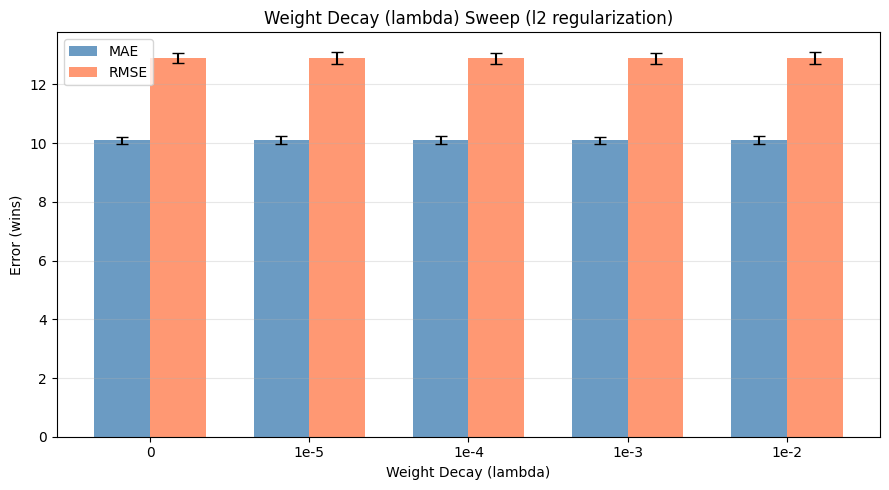

<Axes: title={'center': 'Weight Decay (lambda) Sweep (l2 regularization)'}, xlabel='Weight Decay (lambda)', ylabel='Error (wins)'>

In [46]:
plot_sweep_results(wd_results, param_name='Weight Decay (lambda)', title_suffix=' (l2 regularization)', save_path=os.path.join(RESULTS_DIR, 'step2_weight_decay_sweep.png'), show=True)

In [49]:
best_wd_label = min(wd_results, key=lambda k: wd_results[k]['mae_mean'])
best_wd_value = wd_results[best_wd_label]['value']
print(f"Best weight decay: {best_wd_label} (MAE={wd_results[best_wd_label]['mae_mean']:.2f})")

Best weight decay: 1e-3 (MAE=10.09)


---
## Step 3 — Dropout

p ∈ {0, 0.1, 0.2, 0.3, 0.5}, 3 seeds each.

In [ ]:
print('Step 3: Dropout sweep')
drop_results = run_dropout_sweep(X_train, y_train, X_test, y_test, n_seeds=3)

Step 3: Dropout sweep
  dropout=0 ... MAE=10.61+/-0.06  RMSE=13.59+/-0.06
  dropout=0.1 ... MAE=10.30+/-0.13  RMSE=13.17+/-0.20
  dropout=0.2 ... MAE=10.10+/-0.13  RMSE=12.90+/-0.18
  dropout=0.3 ... MAE=10.06+/-0.32  RMSE=12.78+/-0.45
  dropout=0.5 ... MAE=10.08+/-0.49  RMSE=12.66+/-0.56


In [45]:
print(f"{'Dropout':<14} {'MAE mean':>10} {'MAE std':>10} {'RMSE mean':>10} {'RMSE std':>10}")
print('----------------------------------------------------------')
for label, res in drop_results.items():
    print(f"{label:<14} {res['mae_mean']:>10.2f} {res['mae_std']:>10.2f} {res['rmse_mean']:>10.2f} {res['rmse_std']:>10.2f}")

Dropout          MAE mean    MAE std  RMSE mean   RMSE std
----------------------------------------------------------
0                   10.61       0.06      13.59       0.06
0.1                 10.30       0.13      13.17       0.20
0.2                 10.10       0.13      12.90       0.18
0.3                 10.06       0.32      12.78       0.45
0.5                 10.08       0.49      12.66       0.56


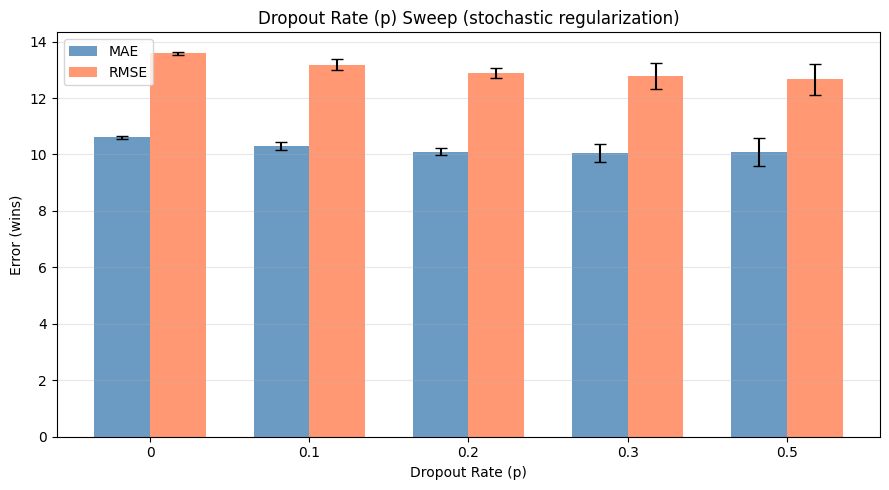

<Axes: title={'center': 'Dropout Rate (p) Sweep (stochastic regularization)'}, xlabel='Dropout Rate (p)', ylabel='Error (wins)'>

In [50]:
plot_sweep_results(drop_results, param_name='Dropout Rate (p)', title_suffix=' (stochastic regularization)', save_path=os.path.join(RESULTS_DIR, 'step3_dropout_sweep.png'), show=True)

In [51]:
best_drop_label = min(drop_results, key=lambda k: drop_results[k]['mae_mean'])
best_drop_value = drop_results[best_drop_label]['value']
print(f"Best dropout: {best_drop_label} (MAE={drop_results[best_drop_label]['mae_mean']:.2f})")

Best dropout: 0.3 (MAE=10.06)


---
## Step 4 — Batch size

B ∈ {16, 32, 64}, 3 seeds each.

In [52]:
print('Step 4: Batch size')
bs_results = run_batch_size_sweep(X_train, y_train, X_test, y_test, n_seeds=3)

Step 4: Batch size
  batch_size=16 ... MAE=9.78+/-0.26  RMSE=12.41+/-0.40
  batch_size=32 ... MAE=10.10+/-0.13  RMSE=12.90+/-0.18
  batch_size=64 ... MAE=10.34+/-0.16  RMSE=13.11+/-0.22


In [53]:
# table
print(f"{'Batch Size':<14} {'MAE mean':>10} {'MAE std':>10} {'RMSE mean':>10} {'RMSE std':>10}")
print('----------------------------------------------------------')
for label, res in bs_results.items():
    print(f"{label:<14} {res['mae_mean']:>10.2f} {res['mae_std']:>10.2f} {res['rmse_mean']:>10.2f} {res['rmse_std']:>10.2f}")

Batch Size       MAE mean    MAE std  RMSE mean   RMSE std
----------------------------------------------------------
16                   9.78       0.26      12.41       0.40
32                  10.10       0.13      12.90       0.18
64                  10.34       0.16      13.11       0.22


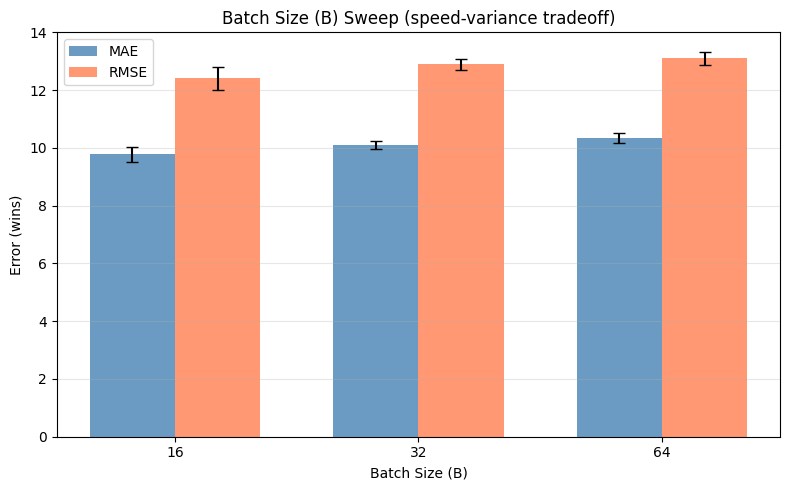

<Axes: title={'center': 'Batch Size (B) Sweep (speed-variance tradeoff)'}, xlabel='Batch Size (B)', ylabel='Error (wins)'>

In [54]:
plot_sweep_results(bs_results, param_name='Batch Size (B)', title_suffix=' (speed-variance tradeoff)', save_path=os.path.join(RESULTS_DIR, 'step4_batch_size_sweep.png'), show=True)

In [55]:
best_bs_label = min(bs_results, key=lambda k: bs_results[k]['mae_mean'])
best_bs_value = bs_results[best_bs_label]['value']
print(f"Best batch size: {best_bs_label} (MAE={bs_results[best_bs_label]['mae_mean']:.2f})")

Best batch size: 16 (MAE=9.78)


---
## Step 5 — Learning rate

η ∈ {3e-4, 1e-3, 3e-3}, 3 seeds each.

In [56]:
print('Step 5: Learning rate')
lr_results = run_learning_rate_sweep(X_train, y_train, X_test, y_test, n_seeds=3)

Step 5: Learning rate
  lr=3e-4 ... MAE=11.92+/-0.12  RMSE=15.12+/-0.18
  lr=1e-3 ... MAE=10.10+/-0.13  RMSE=12.90+/-0.18
  lr=3e-3 ... MAE=9.97+/-0.18  RMSE=12.61+/-0.24


In [57]:
# table
print(f"{'LR':<14} {'MAE mean':>10} {'MAE std':>10} {'RMSE mean':>10} {'RMSE std':>10}")
print('----------------------------------------------------------')
for label, res in lr_results.items():
    print(f"{label:<14} {res['mae_mean']:>10.2f} {res['mae_std']:>10.2f} {res['rmse_mean']:>10.2f} {res['rmse_std']:>10.2f}")

LR               MAE mean    MAE std  RMSE mean   RMSE std
----------------------------------------------------------
3e-4                11.92       0.12      15.12       0.18
1e-3                10.10       0.13      12.90       0.18
3e-3                 9.97       0.18      12.61       0.24


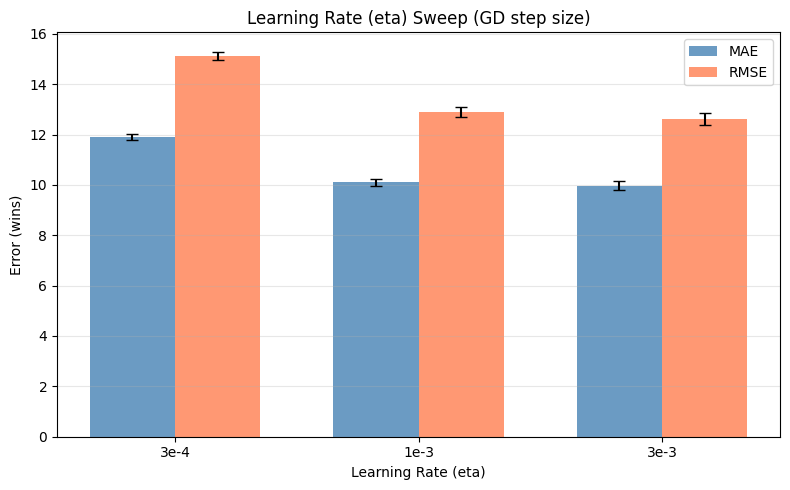

<Axes: title={'center': 'Learning Rate (eta) Sweep (GD step size)'}, xlabel='Learning Rate (eta)', ylabel='Error (wins)'>

In [58]:
plot_sweep_results(lr_results, param_name='Learning Rate (eta)', title_suffix=' (GD step size)', save_path=os.path.join(RESULTS_DIR, 'step5_learning_rate_sweep.png'), show=True)

In [59]:
best_lr_label = min(lr_results, key=lambda k: lr_results[k]['mae_mean'])
best_lr_value = lr_results[best_lr_label]['value']
print(f"Best learning rate: {best_lr_label} (MAE={lr_results[best_lr_label]['mae_mean']:.2f})")

Best learning rate: 3e-3 (MAE=9.97)


---
## Step 6 — Tuned model (combine best hyperparams, 5 seeds)


In [60]:
print('Step 6: Tuned model')
print('Best weight_decay: ', str(best_wd_value))
print('Best dropout: ', str(best_drop_value))
print('Best batch_size: ', str(best_bs_value))
print('Best lr: ', str(best_lr_value))
print()

tuned_ms = run_multi_seed(X_train, y_train, X_test, y_test, n_seeds=5, weight_decay=best_wd_value, dropout=best_drop_value, batch_size=best_bs_value, lr=best_lr_value)

print("Tuned results (5 seeds):")
print(f"  MAE:  {tuned_ms['mae_mean']:.2f} +/- {tuned_ms['mae_std']:.2f}")
print(f"  RMSE: {tuned_ms['rmse_mean']:.2f} +/- {tuned_ms['rmse_std']:.2f}")

Step 6: Tuned model
Best weight_decay:  0.001
Best dropout:  0.3
Best batch_size:  16
Best lr:  0.003

Tuned results (5 seeds):
  MAE:  9.62 +/- 0.22
  RMSE: 12.37 +/- 0.35


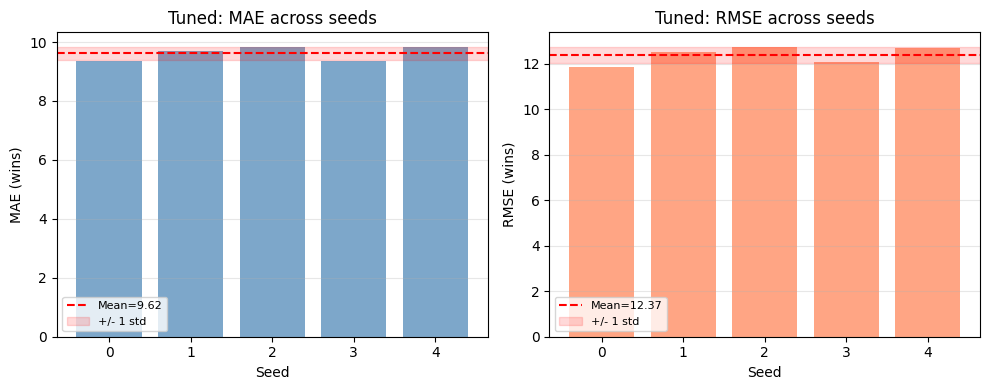

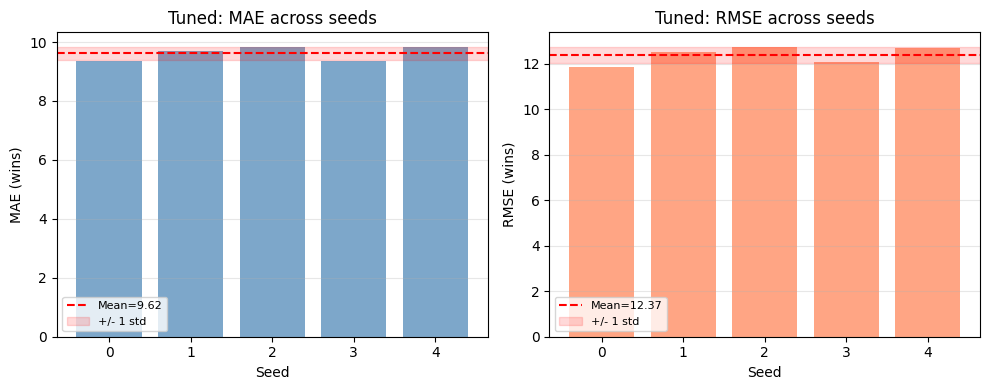

In [61]:
plot_multi_seed_distribution(tuned_ms, model_name='Tuned', save_path=os.path.join(RESULTS_DIR, 'step6_tuned_multi_seed.png'), show=True)

---
## Final Comparison: Pythagorean vs Default NN vs Tuned NN

In [62]:
# baseline
test_df = data['test']
pyth_preds = pythagorean_predict(test_df['R_prev'].values, test_df['RA_prev'].values, games=test_df['G'].values)
pyth_mae  = compute_mae(y_test, pyth_preds)
pyth_rmse = compute_rmse(y_test, pyth_preds)

final_comparison = {
    'Pythagorean\n(no learning)': {
        'mae_mean': pyth_mae, 'mae_std': 0,
        'rmse_mean': pyth_rmse, 'rmse_std': 0,
    },
    'NN Default\n(5 seeds)': {
        'mae_mean': baseline_ms['mae_mean'], 'mae_std': baseline_ms['mae_std'],
        'rmse_mean': baseline_ms['rmse_mean'], 'rmse_std': baseline_ms['rmse_std']
    },
    'NN Tuned\n(5 seeds)': {
        'mae_mean': tuned_ms['mae_mean'], 'mae_std': tuned_ms['mae_std'],
        'rmse_mean': tuned_ms['rmse_mean'], 'rmse_std': tuned_ms['rmse_std']
    }
}

# print table
print(f"{'Model':<25} {'MAE':>14} {'RMSE':>14}")
print('-------------------------------------------------------')
for name, res in final_comparison.items():
    name_clean = name.replace('\n', ' ')
    mae_str  = f"{res['mae_mean']:.2f}"
    rmse_str = f"{res['rmse_mean']:.2f}"
    if res['mae_std'] > 0:
        mae_str  += f" +/- {res['mae_std']:.2f}"
        rmse_str += f" +/- {res['rmse_std']:.2f}"
    print(f"{name_clean:<25} {mae_str:>14} {rmse_str:>14}")

Model                                MAE           RMSE
-------------------------------------------------------
Pythagorean (no learning)          10.73          13.48
NN Default (5 seeds)      10.07 +/- 0.16 12.93 +/- 0.22
NN Tuned (5 seeds)         9.62 +/- 0.22 12.37 +/- 0.35


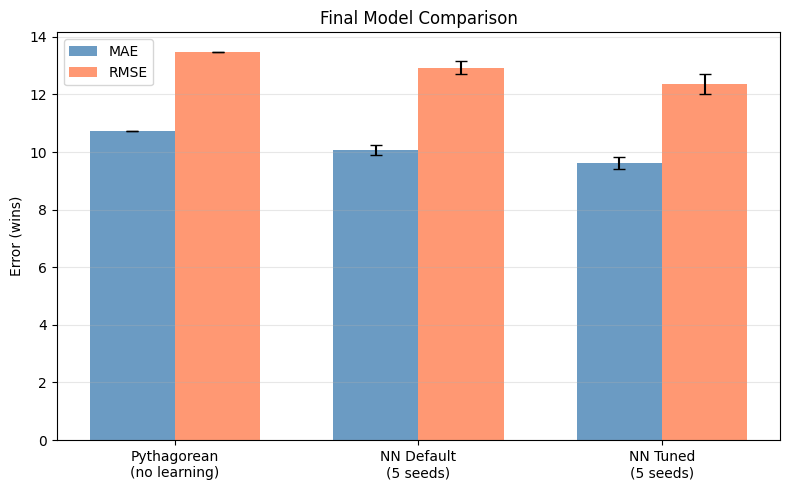

<Axes: title={'center': 'Final Model Comparison'}, ylabel='Error (wins)'>

In [63]:
plot_final_comparison(final_comparison, save_path=os.path.join(RESULTS_DIR, 'step6_final_comparison.png'), show=True)

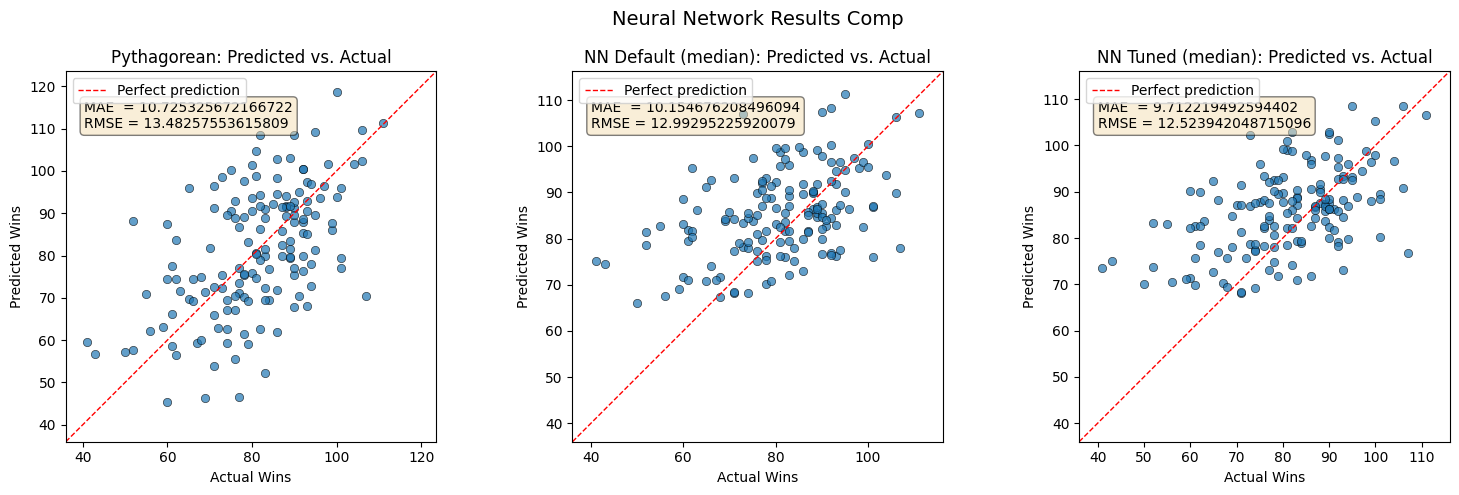

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_pred_vs_actual(y_test, pyth_preds, model_name='Pythagorean', ax=axes[0])

default_median_idx = int(np.argsort(baseline_ms['maes'])[len(baseline_ms['maes']) // 2])
plot_pred_vs_actual(y_test, baseline_ms['per_seed'][default_median_idx]['preds'], model_name='NN Default (median)', ax=axes[1])

tuned_median_idx = int(np.argsort(tuned_ms['maes'])[len(tuned_ms['maes']) // 2])
plot_pred_vs_actual(y_test, tuned_ms['per_seed'][tuned_median_idx]['preds'], model_name='NN Tuned (median)', ax=axes[2])

fig.suptitle('Neural Network Results Comp', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'step6_three_way_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()